# SMART Dataset — Exploratory Data Analysis

**Dataset:** 175 ICU patient time series files (long format: one row per measurement)  
**Columns per file:** `Feature`, `Value`, `Unit`, `Time`  
**Goal:** Understand data quality, coverage, and feature distributions before modeling.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('data')
patient_files = sorted(DATA_DIR.glob('ID_*.csv'))
print(f'Found {len(patient_files)} patient files')

Found 175 patient files


## 1. Load all patient data

In [37]:
all_dfs = []
load_errors = []

for f in patient_files:
    try:
        df = pd.read_csv(f, parse_dates=['Time'], encoding='latin-1')
        df['patient_id'] = f.stem  # e.g. 'ID_001'
        all_dfs.append(df)
    except Exception as e:
        load_errors.append((f.stem, str(e)))

if load_errors:
    print('Files that failed to load:')
    for pid, err in load_errors:
        print(f'  {pid}: {err}')

full_df = pd.concat(all_dfs, ignore_index=True)
print(f'Total rows: {len(full_df):,}')
print(f'Columns: {list(full_df.columns)}')
full_df.head()


Total rows: 1,945,892
Columns: ['Feature', 'Value', 'Unit', 'Time', 'patient_id']


,Feature,Value,Unit,Time,patient_id
0,CO2 Konzentration Endtidal in mmHg,7.0,mmHg,2021-03-21 06:08:00,ID_001
1,CO2 Konzentration Endtidal in mmHg,48.0,mmHg,2021-03-21 06:23:00,ID_001
2,CO2 Konzentration Endtidal in mmHg,48.0,mmHg,2021-03-21 06:38:00,ID_001
3,CO2 Konzentration Endtidal in mmHg,59.0,mmHg,2021-03-21 06:53:00,ID_001
4,CO2 Konzentration Endtidal in mmHg,58.0,mmHg,2021-03-21 07:08:00,ID_001


## 2. Per-patient summary: row count, time span, date range

In [38]:
patient_summary = full_df.groupby('patient_id').agg(
    n_rows=('Feature', 'count'),
    n_unique_features=('Feature', 'nunique'),
    first_timestamp=('Time', 'min'),
    last_timestamp=('Time', 'max'),
).reset_index()

patient_summary['duration_days'] = (
    patient_summary['last_timestamp'] - patient_summary['first_timestamp']
).dt.total_seconds() / 86400

patient_summary['year'] = patient_summary['first_timestamp'].dt.year

print(patient_summary.describe())
patient_summary.sort_values('n_rows').head(10)

             n_rows  n_unique_features                first_timestamp  \
count    175.000000         175.000000                            175   
mean   11119.382857          70.794286  2021-06-22 16:53:38.742857216   
min        9.000000           5.000000            2013-04-23 13:13:00   
25%     4412.500000          66.000000            2020-04-15 13:14:30   
50%     9295.000000          76.000000            2021-05-31 19:41:00   
75%    15694.000000          83.000000            2022-08-07 11:59:00   
max    77357.000000          88.000000            2024-05-11 23:44:00   
std     9954.983205          16.108218                            NaN   

                      last_timestamp  duration_days         year  
count                            175     175.000000   175.000000  
mean   2021-08-06 05:26:55.199999744      44.523107  2020.977143  
min              2019-04-01 02:45:00       0.000000  2013.000000  
25%              2020-05-01 14:34:00       7.282639  2020.000000  
50%    

,patient_id,n_rows,n_unique_features,first_timestamp,last_timestamp,duration_days,year
99,ID_100,9,5,2019-04-30 11:45:00,2019-05-02 07:15:00,1.812500,2019
115,ID_116,30,29,2019-04-21 10:45:00,2019-04-21 10:45:00,0.000000,2019
89,ID_090,30,29,2019-06-02 09:15:00,2019-06-02 09:15:00,0.000000,2019
151,ID_152,34,29,2019-05-16 08:15:00,2019-05-20 09:15:00,4.041667,2019
96,ID_097,38,37,2019-07-29 08:00:00,2019-07-29 08:00:00,0.000000,2019
36,ID_037,48,41,2019-05-06 14:22:00,2019-05-07 11:15:00,0.870139,2019
2,ID_003,61,36,2019-04-01 02:00:00,2019-04-01 02:45:00,0.031250,2019
154,ID_155,63,35,2019-08-19 22:44:00,2019-08-19 23:16:00,0.022222,2019
153,ID_154,74,36,2019-04-18 20:30:00,2019-04-18 21:17:00,0.032639,2019
118,ID_119,75,37,2019-12-18 10:15:00,2019-12-18 21:15:00,0.458333,2019


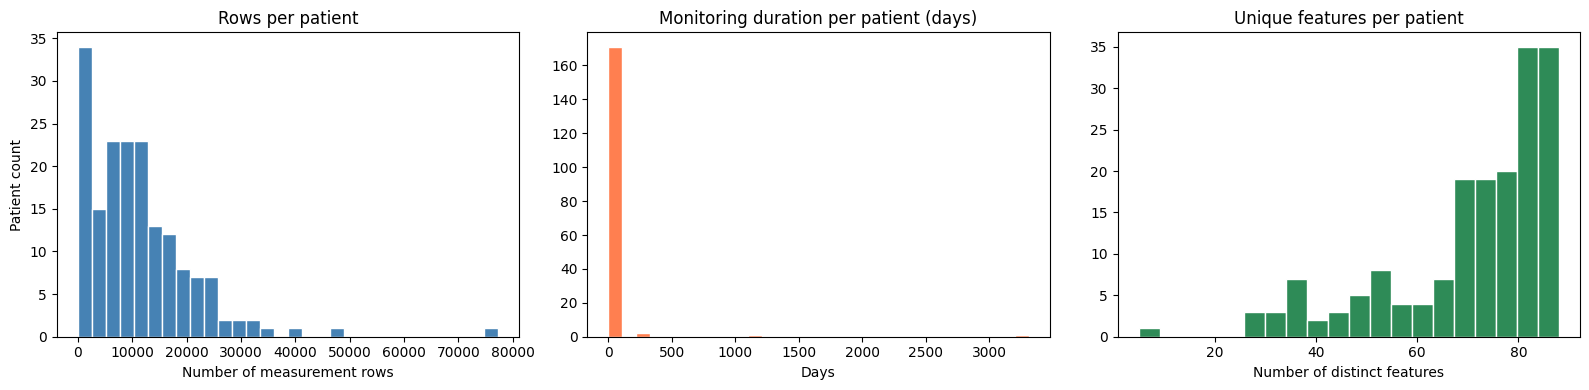

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(patient_summary['n_rows'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Rows per patient')
axes[0].set_xlabel('Number of measurement rows')
axes[0].set_ylabel('Patient count')

axes[1].hist(patient_summary['duration_days'].dropna(), bins=30, color='coral', edgecolor='white')
axes[1].set_title('Monitoring duration per patient (days)')
axes[1].set_xlabel('Days')

axes[2].hist(patient_summary['n_unique_features'], bins=20, color='seagreen', edgecolor='white')
axes[2].set_title('Unique features per patient')
axes[2].set_xlabel('Number of distinct features')

plt.tight_layout()
plt.savefig('data/fig_patient_overview.png', dpi=120)
plt.show()

In [40]:
# Flag patients with very few rows or very short duration
LOW_ROW_THRESHOLD = 100
SHORT_DURATION_THRESHOLD = 1  # days

sparse_patients = patient_summary[
    (patient_summary['n_rows'] < LOW_ROW_THRESHOLD) |
    (patient_summary['duration_days'] < SHORT_DURATION_THRESHOLD)
].sort_values('n_rows')

print(f'Patients with <{LOW_ROW_THRESHOLD} rows OR <{SHORT_DURATION_THRESHOLD} day duration: {len(sparse_patients)}')
sparse_patients[['patient_id', 'n_rows', 'duration_days', 'n_unique_features', 'year']]

Patients with <100 rows OR <1 day duration: 16


,patient_id,n_rows,duration_days,n_unique_features,year
99,ID_100,9,1.812500,5,2019
89,ID_090,30,0.000000,29,2019
115,ID_116,30,0.000000,29,2019
151,ID_152,34,4.041667,29,2019
96,ID_097,38,0.000000,37,2019
36,ID_037,48,0.870139,41,2019
2,ID_003,61,0.031250,36,2019
154,ID_155,63,0.022222,35,2019
153,ID_154,74,0.032639,36,2019
118,ID_119,75,0.458333,37,2019


## 3. Feature coverage across patients (using Feature_File_Count_Summary.csv)

In [41]:
feat_summary = pd.read_csv(DATA_DIR / 'Feature_File_Count_Summary.csv', encoding='latin-1')
feat_summary.columns = feat_summary.columns.str.strip()
feat_summary = feat_summary.sort_values('File_Count', ascending=False).reset_index(drop=True)

n_patients = len(patient_files)
feat_summary['coverage_pct'] = feat_summary['File_Count'] / n_patients * 100

print(f'Total unique features: {len(feat_summary)}')
print(f'Features present in >90% of patients: {(feat_summary["coverage_pct"] > 90).sum()}')
print(f'Features present in <50% of patients: {(feat_summary["coverage_pct"] < 50).sum()}')

feat_summary.head(20)


Total unique features: 88
Features present in >90% of patients: 34
Features present in <50% of patients: 5


,Feature,File_Count,coverage_pct
0,Calcium,175,100.000000
1,Natrium,175,100.000000
2,Target: mRS score,175,100.000000
3,Kalium,175,100.000000
4,Chlorid,175,100.000000
5,Hämatokrit,174,99.428571
6,Eryth.-Verteilungsbr.,174,99.428571
7,Hämoglobin,174,99.428571
8,Harnstoff,174,99.428571
9,Glucose,174,99.428571


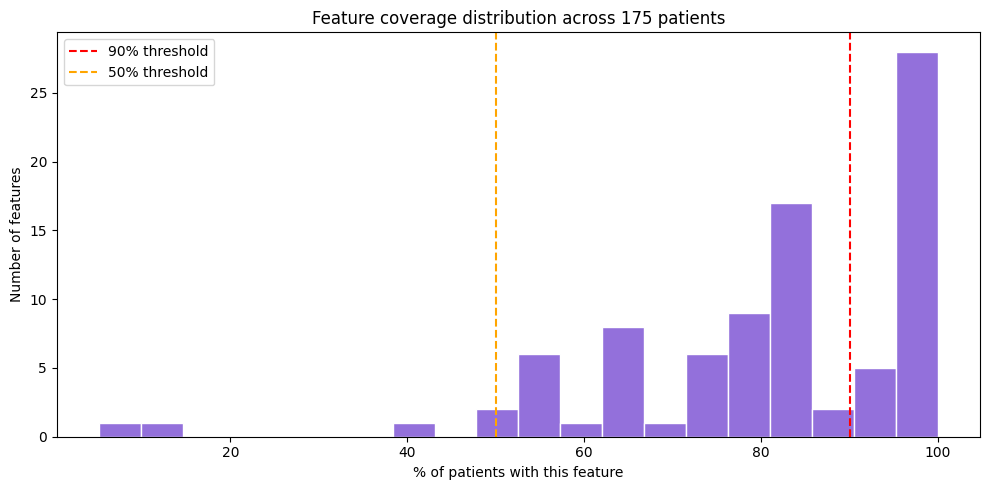

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(feat_summary['coverage_pct'], bins=20, color='mediumpurple', edgecolor='white')
ax.set_xlabel('% of patients with this feature')
ax.set_ylabel('Number of features')
ax.set_title('Feature coverage distribution across 175 patients')
ax.axvline(90, color='red', linestyle='--', label='90% threshold')
ax.axvline(50, color='orange', linestyle='--', label='50% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('data/fig_feature_coverage.png', dpi=120)
plt.show()

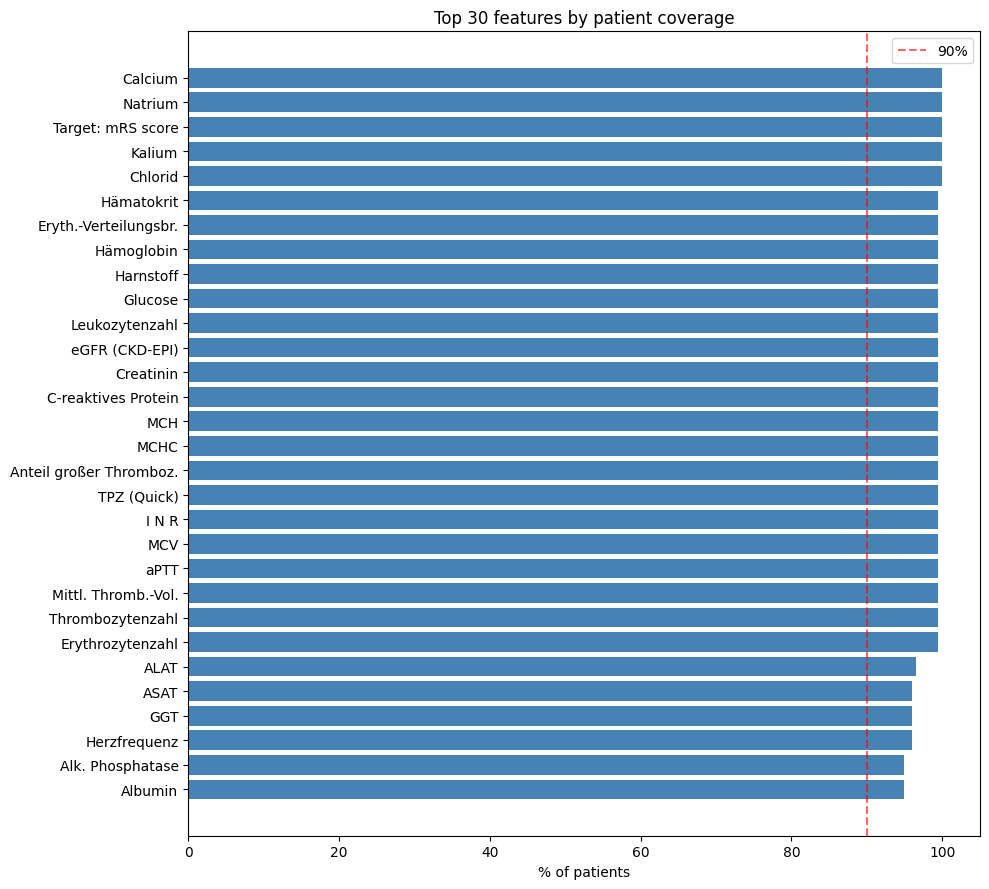

In [43]:
# Top 30 most common features
top30 = feat_summary.head(30)

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(top30['Feature'][::-1], top30['coverage_pct'][::-1], color='steelblue')
ax.set_xlabel('% of patients')
ax.set_title('Top 30 features by patient coverage')
ax.axvline(90, color='red', linestyle='--', alpha=0.6, label='90%')
ax.legend()
plt.tight_layout()
plt.savefig('data/fig_top30_features.png', dpi=120)
plt.show()

## 4. Value distribution and outlier detection for key features

In [44]:
# Coerce Value column to numeric (some might be strings/errors)
full_df['Value_num'] = pd.to_numeric(full_df['Value'], errors='coerce')

non_numeric_rate = full_df['Value_num'].isna().mean() * 100
print(f'Non-numeric value rate: {non_numeric_rate:.2f}%')

# Check what non-numeric values look like
non_numeric_examples = full_df[full_df['Value_num'].isna()]['Value'].value_counts().head(20)
print('\nMost common non-numeric values:')
print(non_numeric_examples)

Non-numeric value rate: 0.37%

Most common non-numeric values:
Value
k.Mat.    37
< 16.7     1
Name: count, dtype: int64


In [45]:
# Distribution stats for all features
feature_stats = full_df.groupby('Feature')['Value_num'].agg(
    count='count',
    mean='mean',
    std='std',
    min='min',
    p25=lambda x: x.quantile(0.25),
    median='median',
    p75=lambda x: x.quantile(0.75),
    max='max',
    n_missing=lambda x: x.isna().sum(),
).reset_index()

feature_stats['missing_pct'] = feature_stats['n_missing'] / len(full_df) * 100
feature_stats = feature_stats.sort_values('count', ascending=False)
print('Feature value statistics (top 20 by count):')
feature_stats.head(20)

Feature value statistics (top 20 by count):


,Feature,count,mean,std,min,p25,median,p75,max,n_missing,missing_pct
34,Herzfrequenz,234071,81.662833,17.734236,0.00,69.00,80.00,93.00,206.00,1,0.000051
56,Mit art Druck,215596,93.996275,22.319887,0.00,82.00,92.00,103.00,360.00,1,0.000051
77,Sys art Druck,210243,139.716928,24.183060,12.00,124.00,140.00,156.00,360.00,1,0.000051
20,Dia art Druck,209621,68.632398,15.562243,11.00,59.00,67.00,76.00,321.00,1,0.000051
75,SaO2 - Überwachung,206008,95.776266,3.526669,0.00,94.00,96.00,98.00,100.00,14,0.000719
81,Temperatur,204639,37.501113,1.050862,-0.44,37.13,37.52,37.96,44.98,22,0.001131
65,O2 Konzentration inspiratorisch,109959,31.937513,10.737166,20.00,25.00,30.00,35.00,174.00,0,0.000000
12,CO2 Konzentration Endtidal in mmHg,107559,43.732863,9.580160,0.00,37.00,44.00,51.00,99.00,0,0.000000
40,ICP (Hirndruck),92432,12.812695,11.032179,-41.00,8.00,12.00,16.00,361.00,72,0.003700
78,Systole NBP,18715,132.126797,22.062761,2.00,117.00,131.00,146.00,266.00,1,0.000051


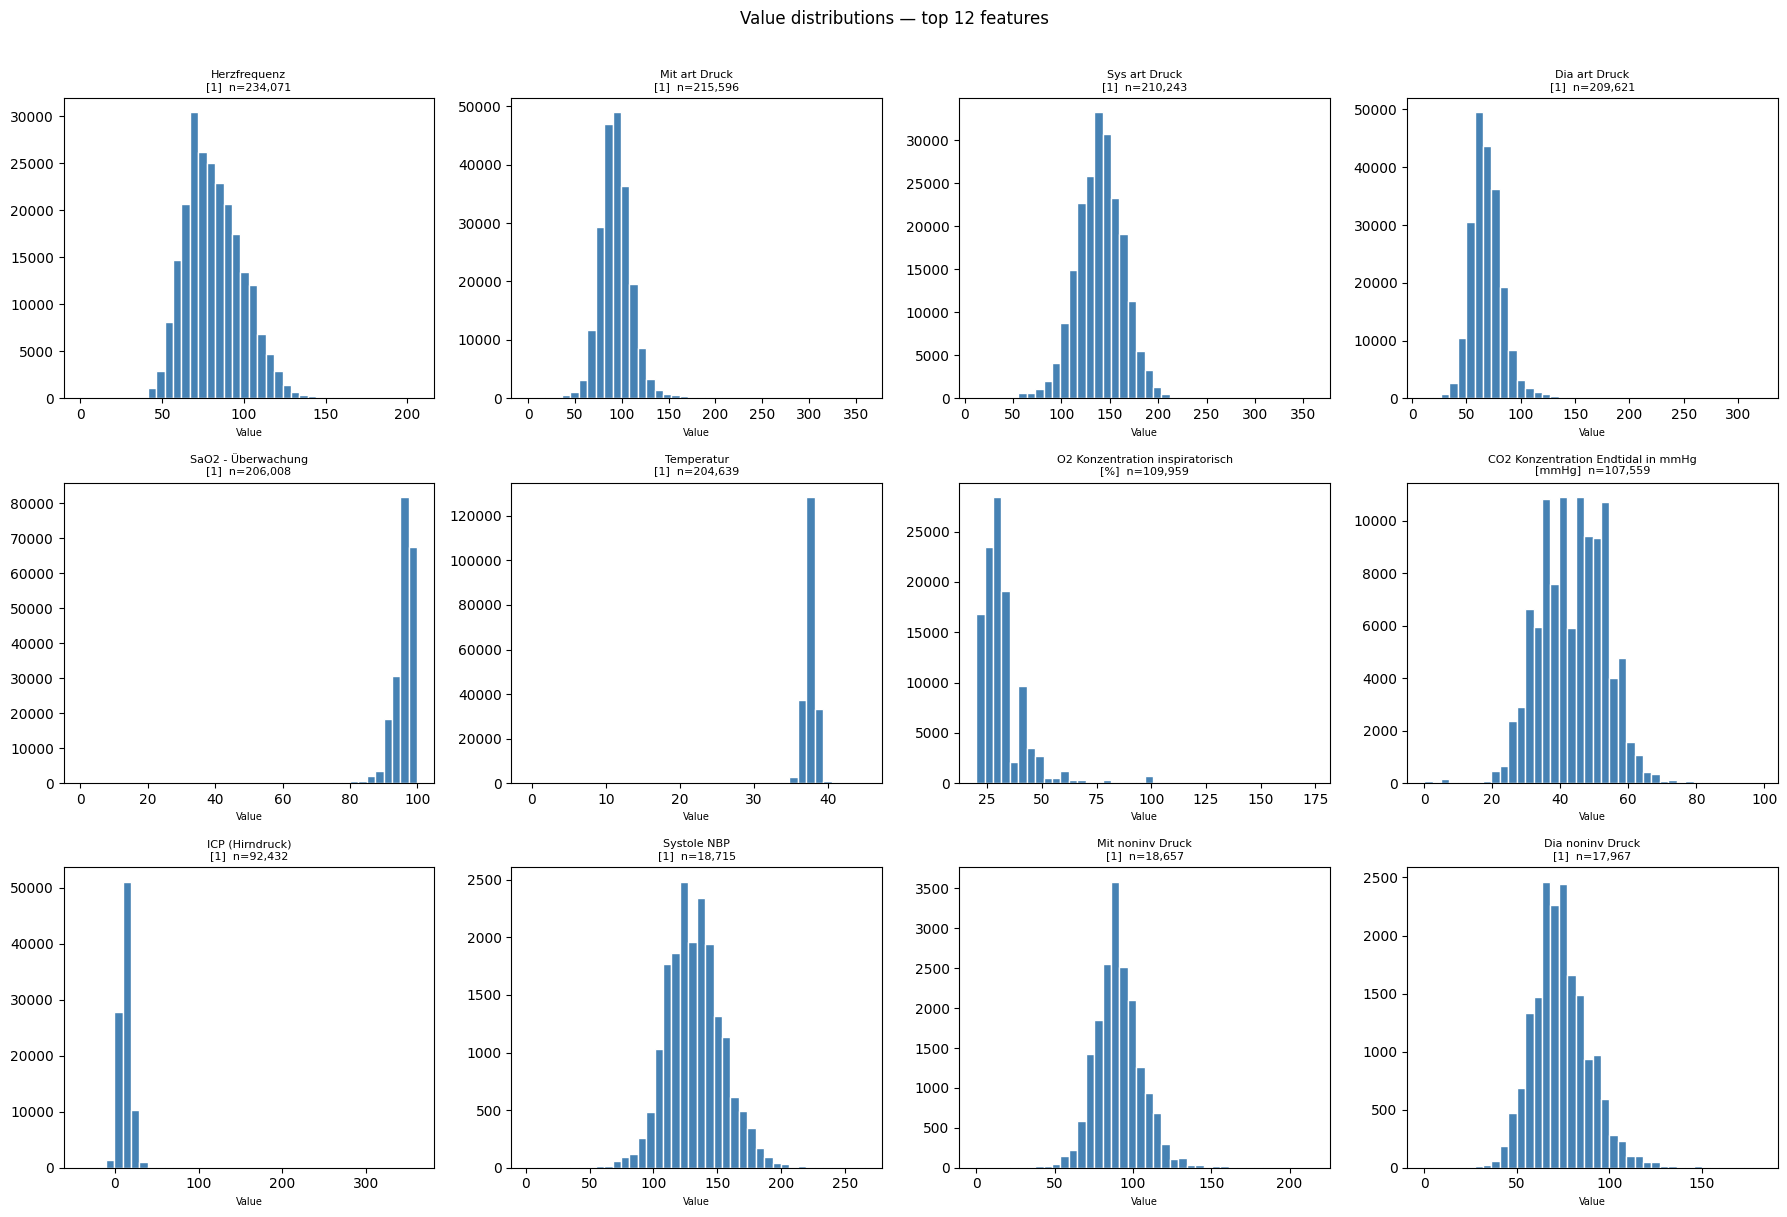

In [46]:
# Plot value distributions for top 12 most frequent features
top_features = feature_stats.head(12)['Feature'].tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    vals = full_df[full_df['Feature'] == feat]['Value_num'].dropna()
    axes[i].hist(vals, bins=40, color='steelblue', edgecolor='white')
    unit = full_df[full_df['Feature'] == feat]['Unit'].dropna().mode()
    unit_str = unit.iloc[0] if len(unit) > 0 else ''
    axes[i].set_title(f'{feat}\n[{unit_str}]  n={len(vals):,}', fontsize=8)
    axes[i].set_xlabel('Value', fontsize=7)

plt.suptitle('Value distributions — top 12 features', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('data/fig_value_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Outlier detection (IQR method)

In [47]:
def count_outliers_iqr(series, factor=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - factor * iqr, q3 + factor * iqr
    n_out = ((series < lower) | (series > upper)).sum()
    return n_out, round(n_out / len(series) * 100, 2), lower, upper

outlier_report = []
for feat in feature_stats['Feature']:
    vals = full_df[full_df['Feature'] == feat]['Value_num'].dropna()
    if len(vals) < 10:
        continue
    n_out, pct_out, lower, upper = count_outliers_iqr(vals)
    outlier_report.append({
        'Feature': feat,
        'n_values': len(vals),
        'n_outliers': n_out,
        'outlier_pct': pct_out,
        'iqr_lower': round(lower, 3),
        'iqr_upper': round(upper, 3),
        'actual_min': round(vals.min(), 3),
        'actual_max': round(vals.max(), 3),
    })

outlier_df = pd.DataFrame(outlier_report).sort_values('outlier_pct', ascending=False)
print('Features with highest outlier rates (IQR x3):')
outlier_df.head(20)

Features with highest outlier rates (IQR x3):


,Feature,n_values,n_outliers,outlier_pct,iqr_lower,iqr_upper,actual_min,actual_max
79,GLDH,184,19,10.33,-270.250,442.000,15.00,162600.00
72,Zellzahl kernhaltig (gesamt),653,49,7.50,-1279.000,1815.000,2.00,15967.00
69,Leukozyten,654,49,7.49,-1248.500,1772.000,0.00,17640.00
68,Erythrozyten,654,43,6.57,-179750.000,249000.000,0.00,2079000.00
63,Immature Granul.,794,46,5.79,-0.370,0.610,0.01,2.30
17,"Calcium,ionisiert",8479,458,5.40,0.920,1.410,0.69,2.22
81,Lipase,163,8,4.91,-0.480,1.375,0.14,24.82
78,LDH,187,9,4.81,-1.260,8.540,1.73,315.00
33,aPTT,2862,133,4.65,14.700,40.600,21.00,172.10
85,Pank.-Amylase,134,6,4.48,-0.513,1.291,0.05,10.50


## 6. Temporal coverage — admission years and monitoring timelines

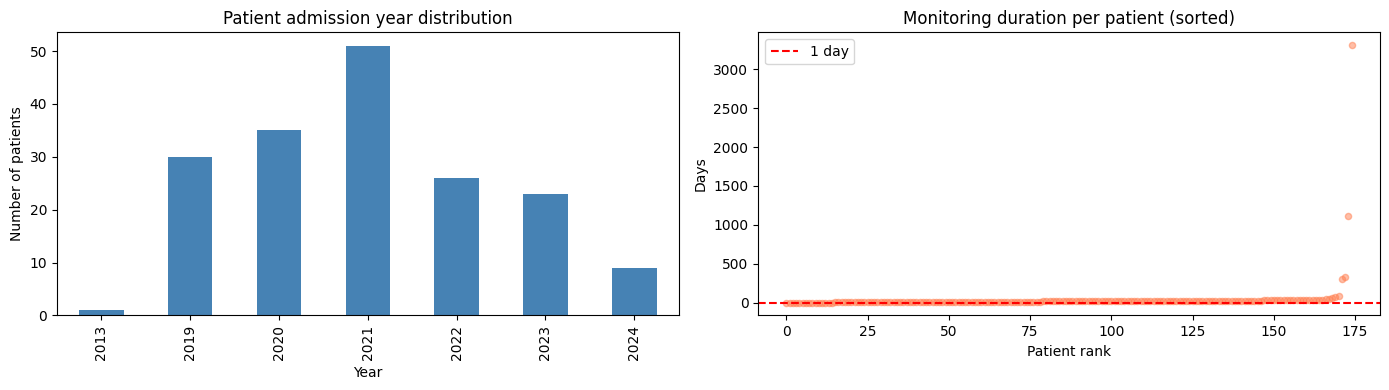

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Year of first admission
patient_summary['year'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Patient admission year distribution')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of patients')

# Monitoring duration scatter
axes[1].scatter(range(len(patient_summary)), patient_summary.sort_values('duration_days')['duration_days'],
               alpha=0.5, color='coral', s=20)
axes[1].set_title('Monitoring duration per patient (sorted)')
axes[1].set_xlabel('Patient rank')
axes[1].set_ylabel('Days')
axes[1].axhline(1, color='red', linestyle='--', label='1 day')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/fig_temporal_coverage.png', dpi=120)
plt.show()

## 7. Missing feature matrix — which features are present for which patients?

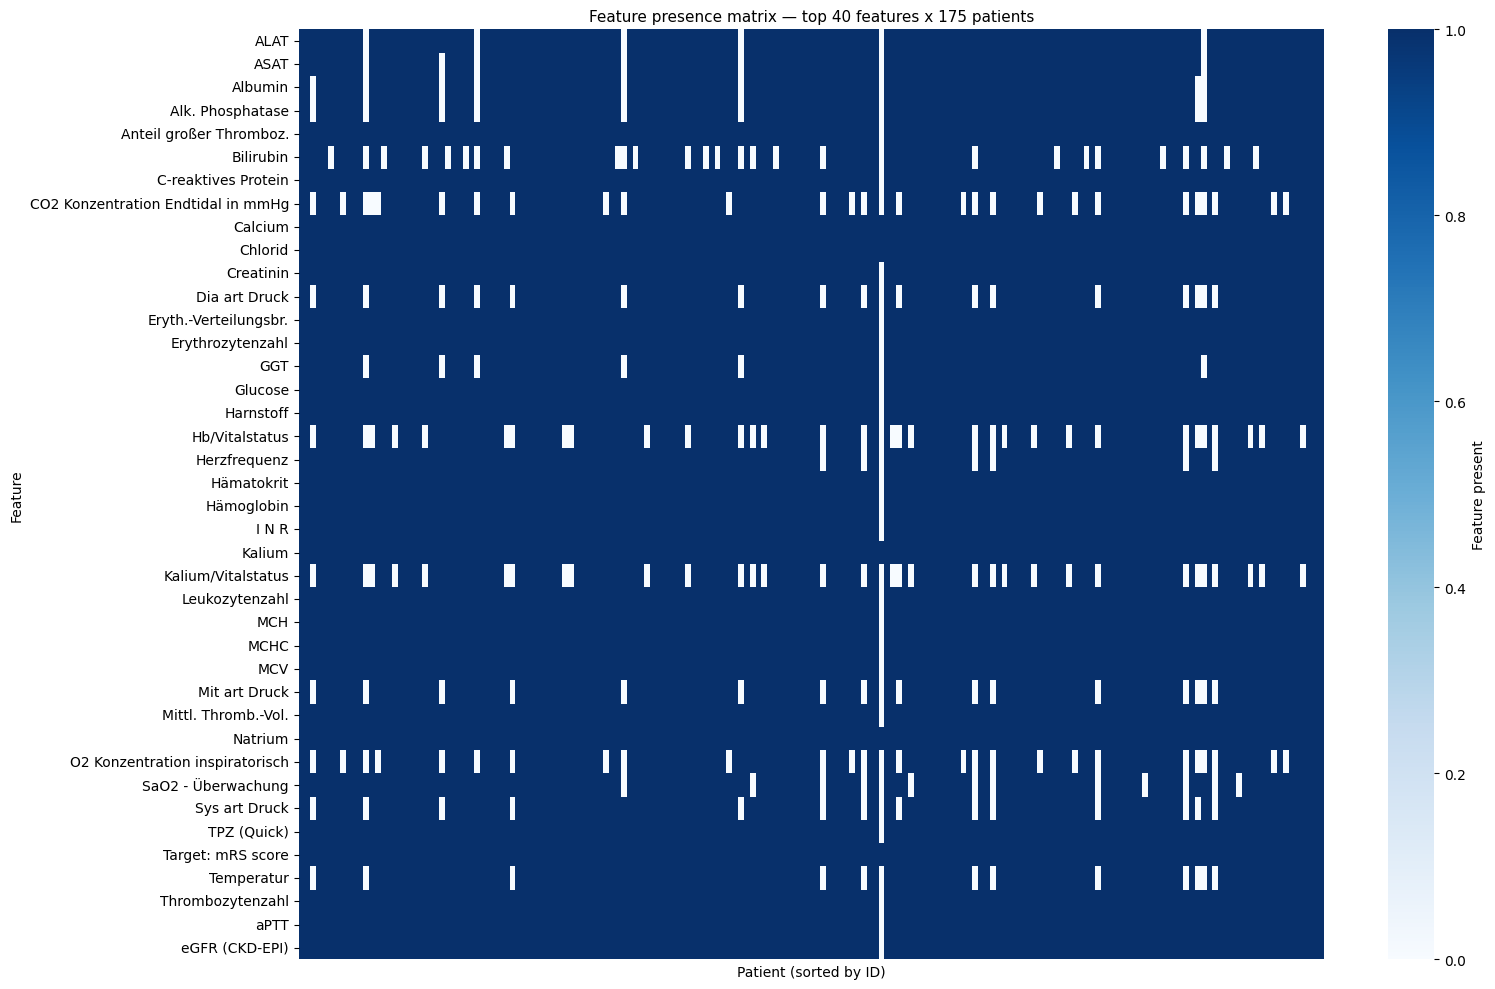

In [49]:
# Use only top 40 features for readability
top40_features = feat_summary.head(40)['Feature'].tolist()

presence_matrix = full_df[full_df['Feature'].isin(top40_features)].groupby(
    ['patient_id', 'Feature']
).size().unstack(fill_value=0)

presence_binary = (presence_matrix > 0).astype(int)

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(presence_binary.T, cmap='Blues', linewidths=0, ax=ax,
            cbar_kws={'label': 'Feature present'}, xticklabels=False)
ax.set_title('Feature presence matrix — top 40 features x 175 patients', fontsize=11)
ax.set_ylabel('Feature')
ax.set_xlabel('Patient (sorted by ID)')
plt.tight_layout()
plt.savefig('data/fig_feature_presence_matrix.png', dpi=120)
plt.show()

## 8. Export summary tables for the meeting

In [50]:
patient_summary.to_csv('data/eda_patient_summary.csv', index=False)
feature_stats.to_csv('data/eda_feature_stats.csv', index=False)
outlier_df.to_csv('data/eda_outlier_report.csv', index=False)

print('Saved:')
print('  data/eda_patient_summary.csv  — one row per patient')
print('  data/eda_feature_stats.csv    — value stats per feature')
print('  data/eda_outlier_report.csv   — outlier rates per feature')
print('  data/fig_*.png                — all plots')

Saved:
  data/eda_patient_summary.csv  — one row per patient
  data/eda_feature_stats.csv    — value stats per feature
  data/eda_outlier_report.csv   — outlier rates per feature
  data/fig_*.png                — all plots


## 9. Key findings summary (fill in after running)

| Question | Finding |
|---|---|
| Total patients | 175 |
| Patients with very few rows (<100) | _fill in_ |
| Patients with very short duration (<1 day) | _fill in_ |
| Total unique features | _fill in_ |
| Features in >90% patients | _fill in_ |
| Features in <50% patients | _fill in_ |
| Non-numeric value rate | _fill in_ |
| Features with highest outlier % | _fill in_ |